# Tarea Semanal 1: Primeros pasos en la simulación
**Autor:** Marco Trabattoni  
**Cátedra:** Procesamiento Digital de Señales - R6051
**Docente:** Mariano Llamedo Soria
 
---
## 1. Introducción y Configuración
En esta sección se importan las librerías necesarias (`NumPy`, `Matplotlib` y `SciPy`) y se definen los parámetros globales de la simulación, como la frecuencia de muestreo y las frecuencias de las señales a generar.

In [1]:
# Importación de módulos que utilizaremos en esta tarea semanal 1:
# Una vez invocadas estas funciones, podremos utilizar los módulos a través 
# del identificador que indicamos luego de "as". 
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

#%% Parámetros de ejemplo
N  = 1000  # 1000 muestras
fs = 1000  # 1000 Hz de muestreo
ff_sen = 20 # 20 Hz para la senoidal
ff_cua = 10 # 10 Hz para la cuadrada
ff_tri = 5 # 5 Hz de triangular

## 2. Definición de Funciones
A continuación, se definen las funciones para generar una señal **Senoidal**, **Cuadrada** y **Triangular**. Cada función devuelve un vector de tiempo `tt` y un vector de amplitud `xx` de dimensiones $N \times 1$.

In [6]:
#%%  Definicion de mi señal senoidal

def MT_Senoidal(vmax=1, dc=0, ff=1, ph=0, nn=100, fs=100):
    
    """
    Genera una señal senoidal con los siguientes argumentos:
        
    vmax -- Amplitud máxima (Volts)
    dc   -- Valor medio (Volts)
    ff   -- Frecuencia de la senoidal (Hz)
    ph   -- Fase (Radianes)
    nn   -- Cantidad de muestras (#)
    fs   -- Frecuencia de muestreo (Hz)
    
    Retorna:
    tt   -- Vector de tiempo (Nx1)
    xx   -- Vector de amplitud (Nx1)
    
    """
    
    # Calculamos el intervalo entre muestras (periodo de muestreo)
    ts = 1/fs
    
    # Generamos el vector de tiempo tt
    tt = np.arange(0.0, N*ts, ts)
    
    # Generamos el vector de señal xx
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
    
    return tt, xx
    
#%%  Definicion de mi señal cuadrada

def MT_Cuadrada(vmax=1, dc=0, ff=1, ph=0, nn=100, fs=100):
    
    """
    Genera una señal cuadrada con los siguientes argumentos:
        
    vmax -- Amplitud máxima (Volts)
    dc   -- Valor medio (Volts)
    ff   -- Frecuencia de la cuadrada (Hz)
    ph   -- Fase (Radianes)
    nn   -- Cantidad de muestras (#)
    fs   -- Frecuencia de muestreo (Hz)
    
    Retorna:
    tt   -- Vector de tiempo (Nx1)
    xx   -- Vector de amplitud (Nx1)
    
    """
    # Calculamos el intervalo entre muestras (periodo de muestreo)
    ts = 1/fs
    
    # Generamos el vector de tiempo tt
    tt = np.arange(0.0, N*ts, ts)
    
    # Generamos el vector de señal xx
    xx = vmax * signal.square(2 * np.pi * ff * tt + ph) + dc
    
    return tt, xx

#%%  Definicion de mi señal triangular

def MT_Triangular(vmax=1, dc=0, ff=1, ph=0, nn=100, fs=100):
    
    """
    Genera una señal triangular con los siguientes argumentos:
        
    vmax -- Amplitud máxima (Volts)
    dc   -- Valor medio (Volts)
    ff   -- Frecuencia de la triangular (Hz)
    ph   -- Fase (Radianes)
    nn   -- Cantidad de muestras (#)
    fs   -- Frecuencia de muestreo (Hz)
    
    Retorna:
    tt   -- Vector de tiempo (Nx1)
    xx   -- Vector de amplitud (Nx1)
    
    """
    # Calculamos el intervalo entre muestras (periodo de muestreo)
    ts = 1/fs
    
    # Generamos el vector de tiempo tt
    tt = np.arange(0.0, N*ts, ts)
    
    # Generamos el vector de señal xx
    # width=0.5 para simétrica
    # width=0 para diente de sierra
    xx = vmax * signal.sawtooth(2 * np.pi * ff * tt + ph, width=0.5) + dc
    
    return tt, xx


## 3. Generación y Visualización de Señales
Se procede a instanciar las señales utilizando las funciones definidas anteriormente y se grafican para verificar su correcto funcionamiento en el dominio del tiempo.

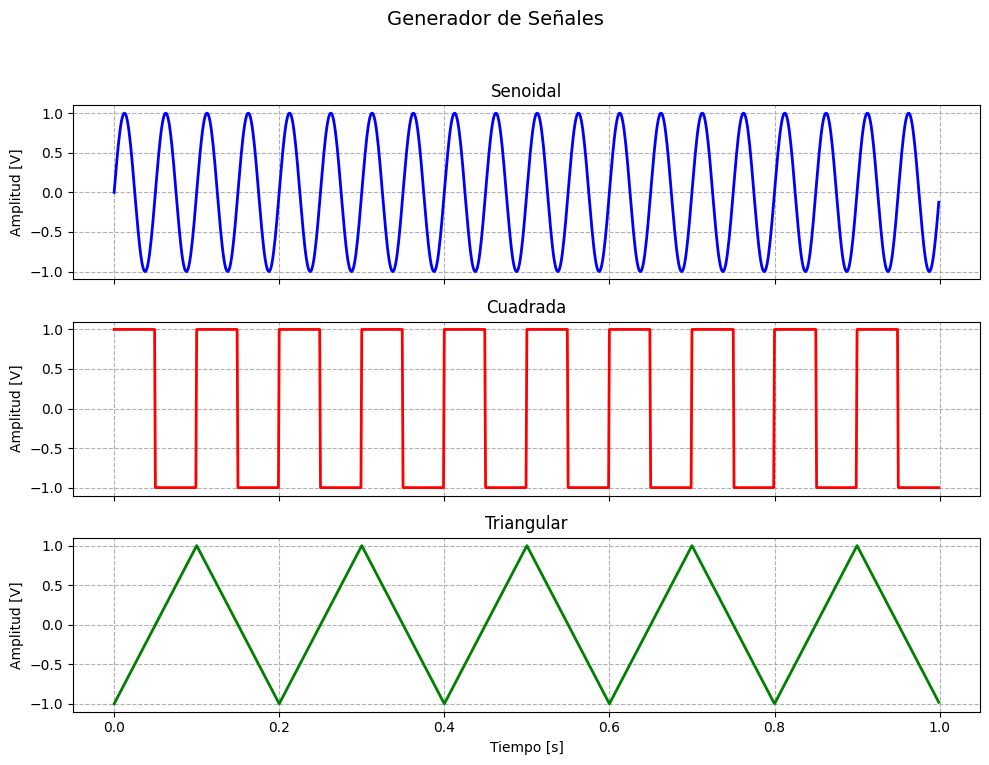

In [8]:
#%%  Ejemplo de uso Senoidal
tt, x_sen = MT_Senoidal(vmax=1, dc=0, ff=ff_sen, ph=0, nn=N, fs=fs)

#%%  Ejemplo de uso Cuadrada
tt, x_cua = MT_Cuadrada(vmax=1, dc=0, ff=ff_cua, ph=0, nn=N, fs=fs)

#%%  Ejemplo de uso Triangular
tt, x_tri = MT_Triangular(vmax=1, dc=0, ff=ff_tri, ph=0, nn=N, fs=fs)

#%%  Graficamos las señales

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig.suptitle('Generador de Señales', fontsize=14)

# Gráfico 1: Senoidal
axs[0].plot(tt, x_sen, color='blue', lw=2)
axs[0].set_ylabel('Amplitud [V]')
axs[0].set_title('Senoidal')
axs[0].grid(True, linestyle='--')

# Gráfico 2: Cuadrada
axs[1].plot(tt, x_cua, color='red', lw=2)
axs[1].set_ylabel('Amplitud [V]')
axs[1].set_title('Cuadrada')
axs[1].grid(True, linestyle='--')

# Gráfico 3: Triangular
axs[2].plot(tt, x_tri, color='green', lw=2)
axs[2].set_ylabel('Amplitud [V]')
axs[2].set_xlabel('Tiempo [s]')
axs[2].set_title('Triangular')
axs[2].grid(True, linestyle='--')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



## 4. Implementación de Ruido y Relación SNR
Se implementa una función que añade ruido blanco gaussiano a una señal dada, permitiendo controlar la relación señal-ruido (**SNR**) en decibeles. Se utiliza la varianza muestral (`np.var`) para estimar la potencia.

In [9]:
#%%  Definicion de mi funcion para añadir ruido

def agregar_ruido_snr(sig, snr_db):
    """
    Suma ruido gaussiano a una señal para obtener un SNR específico.
    
    Argumentos:
    sig    -- Vector de la señal original (Nx1)
    snr_db -- Relación Señal-Ruido deseada en decibeles (dB)
    
    """
    # Calculamos la potencia de la señal original (Varianza)
    p_sig = np.var(sig)
    
    # Calculamos la potencia de ruido necesaria
    p_ruido = p_sig / (10**(snr_db / 10))
    
    # La desviación estándar del ruido es la raíz de su potencia
    sigma_ruido = np.sqrt(p_ruido)
    
    # Generamos el ruido normal (media 0, sigma calculado)
    ruido = np.random.normal(0, sigma_ruido, sig.shape)
    
    # Retornamos la señal ruidosa
    return sig + ruido


## 5. Validación y Análisis de Señales Ruidosas
Finalmente, se aplica un ruido con un **SNR de 10 dB** a las señales generadas y se comparan las potencias calculadas para validar la precisión del generador de ruido.

--- Verificación de Potencias (SNR = 10 dB) ---
Potencia señal senoidal pura: 0.5000 W
Potencia ruido medido:       0.0546 W


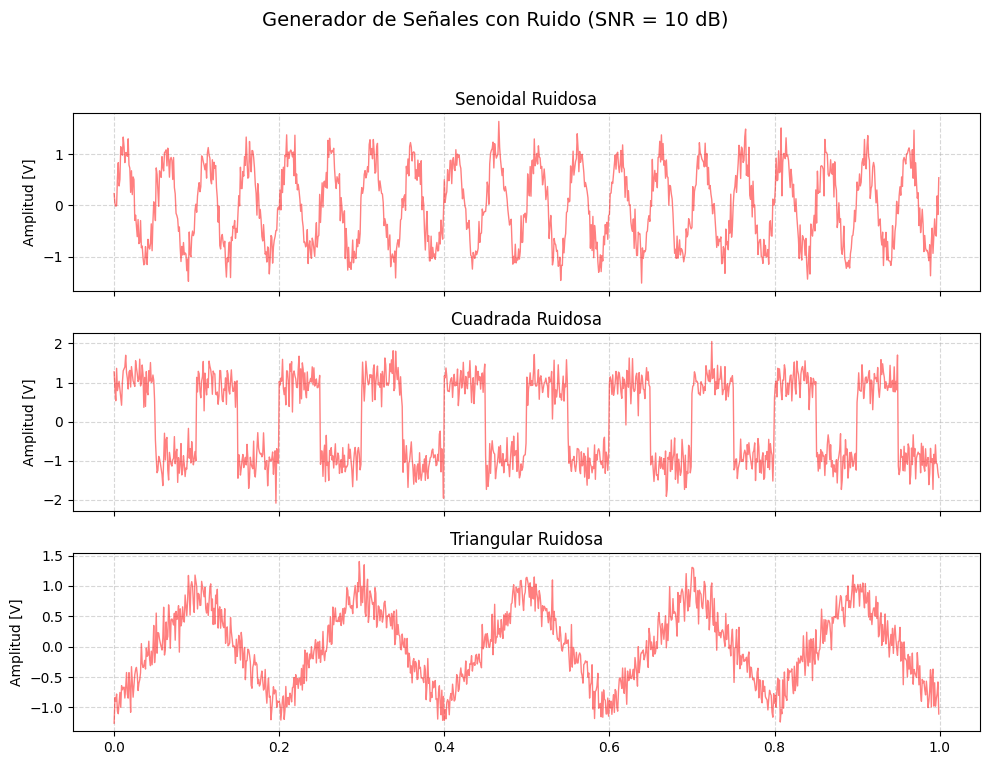

In [5]:
#%%  Ejemplo de uso 

# Generamos una senoidal pura de 1V de amplitud (Potencia = 0.5W si es pura)
t, x_pura = MT_Senoidal(vmax=1, dc=0, ff=ff_sen, nn=1000, fs=1000)

# Le agregamos ruido para un SNR de 10 dB (el ruido tendrá 1/10 de la potencia)
SNR_deseado = 10
x_ruidosa = agregar_ruido_snr(x_pura, SNR_deseado)

# Verificación
print(f"Potencia señal: {np.var(x_pura):.4f} W")
print(f"Potencia ruido: {np.var(x_ruidosa - x_pura):.4f} W")

# Parámetros para las señales puras (sin DC para simplificar la potencia)
params_puros = {'vmax': 1, 'dc': 0, 'ff': 5, 'nn': N, 'fs': fs}

# Generación de señales ruidosas
# Imprimirá las potencias por consola al llamarse
x_sen_ruido = agregar_ruido_snr(x_sen, SNR_deseado)
x_cua_ruido = agregar_ruido_snr(x_cua, SNR_deseado)
x_tri_ruido = agregar_ruido_snr(x_tri, SNR_deseado)

#%%  Graficamos las señales ruidosas

# Creamos la figura con 3 subplots que comparten el eje X
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig.suptitle(f'Generador de Señales con Ruido (SNR = {SNR_deseado} dB)', fontsize=14)

# Estilos de línea
style_ruido = {'color': 'red', 'alpha': 0.5, 'lw': 1, 'label': f'Con Ruido ({SNR_deseado}dB)'}

# Subplot Senoidal
axs[0].plot(t, x_sen_ruido, **style_ruido)
axs[0].set_ylabel('Amplitud [V]')
axs[0].set_title('Senoidal Ruidosa')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend(loc='upper right', fontsize='small')

# Subplot Cuadrada
axs[1].plot(t, x_cua_ruido, **style_ruido)
axs[1].set_ylabel('Amplitud [V]')
axs[1].set_title('Cuadrada Ruidosa')
axs[1].grid(True, linestyle='--', alpha=0.5)

# Subplot Triangular Simétrica
axs[2].plot(t, x_tri_ruido, **style_ruido)
axs[2].set_ylabel('Amplitud [V]')
axs[2].set_xlabel('Tiempo [s]')
axs[2].set_title('Triangular Ruidosa')
axs[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()